In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [2]:
# --------------------------
# Parameters
# --------------------------
# time units in ns
N = 40 # oscillator Hilbert space dimension
w = 2.0 * np.pi * 3.098 # Qubit freq (GHz)
Ej = 2.0 * np.pi * 10 # qubit Ej (GHz)
beta = 0.359 # mode participation
g_0 = 2.0 * np.pi * 5.566 # drive coupling
w_d = 2.0 * np.pi * 0.9755 # subharmonic drive freq (GHz)

# --------------------------
# Operators
# --------------------------
a = qt.destroy(N)
n = a.dag() * a
I = qt.qeye(N)

# --------------------------
# Functions
# --------------------------
def linear_ramp(t, t_r, direction):
    # ramps linearly from 0 to 1
    # if direction == "up": the ramp goes 0 -> 1 from 0 to t_r
    # if direction == "down": the ramp goes 1 -> 0 from 0 to t_r
    if direction == "up":
        if t < 0.0:
            return 0.0
        elif t < t_r:
            return t / t_r
        else:
            return 1.0
    elif direction == "down":
        if t < 0.0:
            return 1.0
        elif t < t_r:
            return 1.0 - t / t_r
        else:
            return 0.0
    else:
        raise ValueError("direction must be 'up' or 'down'")

def drive_function(t, args):
    """
    Returns a real-valued envelope coefficient. The 1j factor lives in the
    operator (see run). args["w_d"] overrides the global w_d if provided.
    """
    wd = args.get("w_d", w_d)
    if t < -args["t_r"]:
        return 0.0
    if t < 0.0:
        return g_0 * linear_ramp(t + args["t_r"], args["t_r"], "up") * np.sin(wd * t)
    if t < args["t_p"]:
        return g_0 * np.sin(wd * t)
    if t < args["t_p"] + args["t_r"]:
        return g_0 * linear_ramp(t - args["t_p"], args["t_r"], "down") * np.sin(wd * t)
    return 0.0

def steady_state_displacement(t):
    return - (g_0/2) * (np.exp(1j * w_d * t) / (w + w_d) - np.exp(-1j * w_d * t) / (w - w_d))

def cosine_nl(x):
    return x.cosm() - I + x**2 / 2

def make_time_array(t_r, t_p, dt):
    t_start = -t_r
    t_end = t_p + t_r
    return np.arange(t_start, t_end + 0.5*dt, dt)

def make_array_endpoints_inclusive(start, end, dx):
    n_steps = int(round((end - start) / dx)) + 1
    return np.linspace(start, end, n_steps)

def displacement(alpha):
    return qt.displace(N, alpha)

H0 = w * n - Ej * cosine_nl(beta * (a + a.dag()))
evals, evecs = H0.eigenstates()

# 1j*(a† - a) is Hermitian; absorbs the imaginary factor from drive_function
drive_op = 1j * (a.dag() - a)

def run(psi_0, times, e_ops, t_r, t_p, w_d_val=None):
    args = {"t_r": t_r, "t_p": t_p}
    if w_d_val is not None:
        args["w_d"] = w_d_val
    H = [
        H0,
        [drive_op, drive_function],
    ]
    res = qt.sesolve(H, psi_0, times, args=args, e_ops=e_ops, options={"store_states": True})
    return res.states, res.expect

def sweep_t_p(psi_0, t_r, t_p_array, dt_sim, e_ops, w_d_val=None):
    """
    Incremental t_p sweep. Simulates ramp-up once, then for each t_p extends
    the plateau by dt_t_p and simulates only the ramp-down.
    Returns dict {"p0": [...], "p1": [...], ...} of final probabilities for each e_op.
    """
    if t_r > 0:
        ramp_up_times = make_array_endpoints_inclusive(-t_r, 0, dt_sim)
        ramp_up_states, _ = run(psi_0, ramp_up_times, [], t_r, t_p=1e9, w_d_val=w_d_val)
        current_state = ramp_up_states[-1]
    else:
        current_state = psi_0

    current_t = 0.0
    results = {f"p{i}": [] for i in range(len(e_ops))}

    for t_p in t_p_array:
        plateau_states, _ = run(current_state, make_array_endpoints_inclusive(current_t, t_p, dt_sim), [], t_r, t_p=1e9, w_d_val=w_d_val)
        current_state = plateau_states[-1]
        current_t = t_p

        ramp_down_states, _ = run(current_state, make_array_endpoints_inclusive(t_p, t_p + t_r, dt_sim), [], t_r, t_p, w_d_val=w_d_val)
        final_state = ramp_down_states[-1]

        for i, op in enumerate(e_ops):
            results[f"p{i}"].append(qt.expect(op, final_state))

    return results

def sweep_2d(psi_0, t_r, t_p_array, w_d_array, dt_sim, e_ops):
    """
    2D sweep over plateau time and drive frequency.
    Returns p1_grid with shape (len(w_d_array), len(t_p_array)).
    """
    p1_grid = np.zeros((len(w_d_array), len(t_p_array)))
    for i, wd in enumerate(w_d_array):
        results = sweep_t_p(psi_0, t_r, t_p_array, dt_sim, e_ops, w_d_val=wd)
        p1_grid[i] = results["p1"]
    return p1_grid

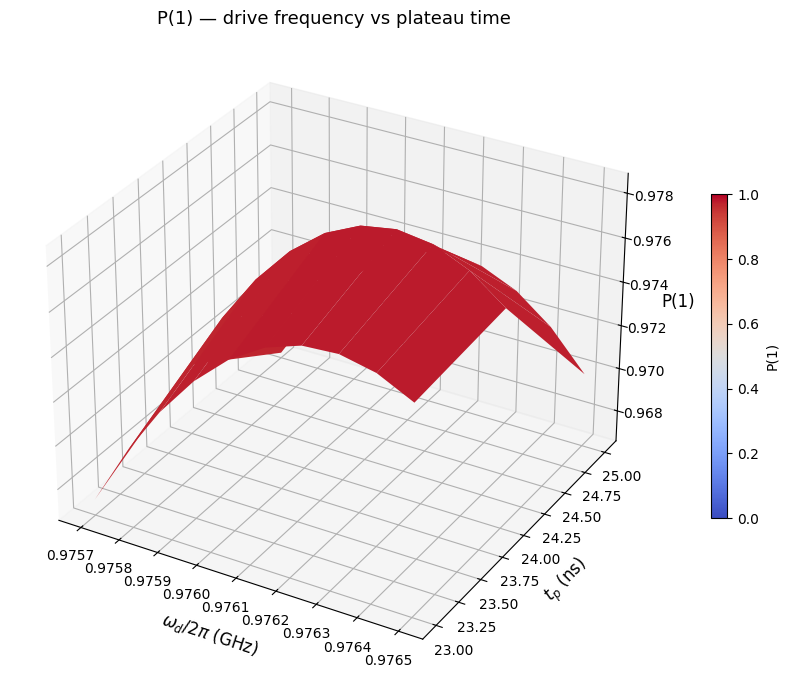

In [4]:
# 2D sweep: plateau time vs drive frequency
dt_sim_2d = 0.01
dt_t_p_2d = 1
t_r_2d = 5.16
t_p_array_2d = make_array_endpoints_inclusive(23, 25, dt_t_p_2d)

# drive frequency axis: sweep around the nominal w_d
w_d_array_2d = 2.0 * np.pi * np.linspace(0.9757, 0.9765, 10)

q0 = evecs[0]
e_ops_2d = [q0*q0.dag(),
            (evecs[1]*evecs[1].dag()),
            (evecs[2]*evecs[2].dag())]

p1_grid = sweep_2d(q0, t_r_2d, t_p_array_2d, w_d_array_2d, dt_sim_2d, e_ops_2d)
# p1_grid shape: (n_freqs, n_tp) — transpose so rows=t_p, cols=freq for imshow
w_d_GHz_array = w_d_array_2d / (2*np.pi)

plot_3d = True  # set True for a 3D surface plot

W, T = np.meshgrid(w_d_GHz_array, t_p_array_2d)  # W, T shape: (n_tp, n_freqs)

if plot_3d:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(W, T, p1_grid.T, cmap="coolwarm", vmin=0, vmax=1, linewidth=0, antialiased=True)
    fig.colorbar(surf, ax=ax, shrink=0.5, label="P(1)")
    ax.set_xlabel(r"$\omega_d / 2\pi$ (GHz)", fontsize=12, labelpad=8)
    ax.set_ylabel(r"$t_p$ (ns)", fontsize=12, labelpad=8)
    ax.set_zlabel("P(1)", fontsize=12)
    ax.set_title("P(1) — drive frequency vs plateau time", fontsize=13)
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(
        p1_grid.T,
        origin="lower",
        aspect="auto",
        extent=[w_d_GHz_array[0], w_d_GHz_array[-1],
                t_p_array_2d[0],  t_p_array_2d[-1]],
        cmap="coolwarm",
        vmin=0, vmax=1,
    )
    plt.colorbar(im, ax=ax, label="P(1)")
    ax.set_xlabel(r"Drive frequency $\omega_d / 2\pi$ (GHz)", fontsize=13)
    ax.set_ylabel(r"Plateau time $t_p$ (ns)", fontsize=13)
    ax.set_title("P(1) — drive frequency vs plateau time", fontsize=13)

plt.tight_layout()
plt.show()

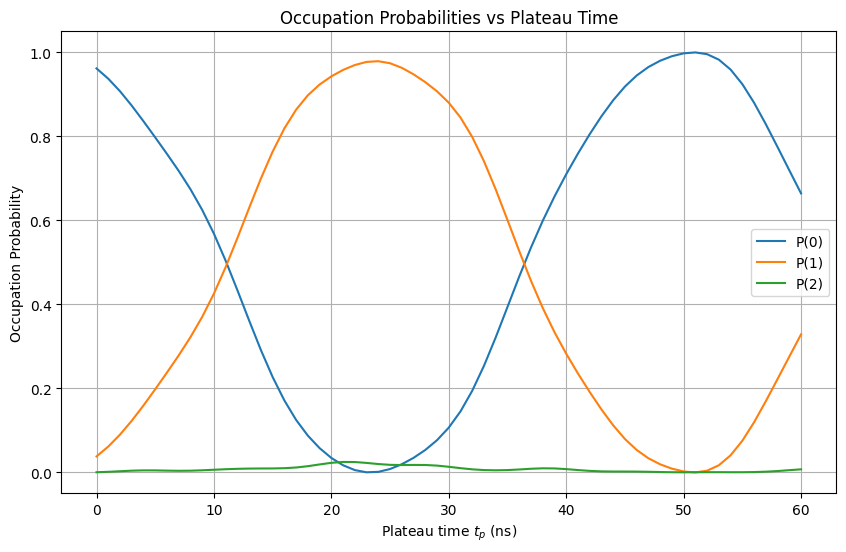

In [5]:
# time grid
dt_sim = 0.01
dt_t_p = 1
t_r = 5.16
t_p_array = np.arange(0, 60.0 + 0.5*dt_t_p, dt_t_p)

q0 = evecs[0]
q1 = evecs[1]
q2 = evecs[2]
e_ops = [q0*q0.dag(), q1*q1.dag(), q2*q2.dag()]

results = sweep_t_p(q0, t_r, t_p_array, dt_sim, e_ops, w_d_val = 2.0 * np.pi * 0.9762)

plt.figure(figsize=(10, 6))
plt.plot(t_p_array, results["p0"], label="P(0)")
plt.plot(t_p_array, results["p1"], label="P(1)")
plt.plot(t_p_array, results["p2"], label="P(2)")
plt.xlabel("Plateau time $t_p$ (ns)")
plt.ylabel("Occupation Probability")
plt.title("Occupation Probabilities vs Plateau Time")
plt.legend()
plt.grid()
plt.show()

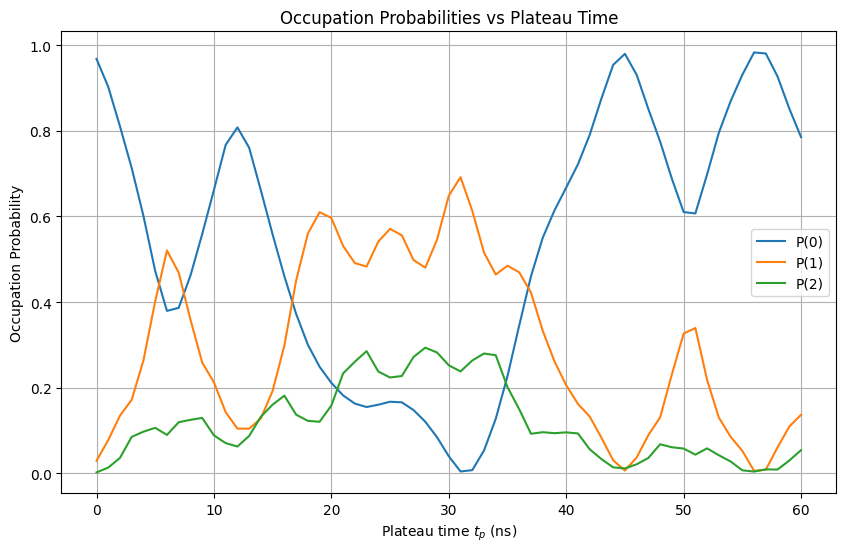

In [6]:
# time grid
dt_sim = 0.01
dt_t_p = 1
t_r = 0.4
t_p_array = np.arange(0, 60.0 + 0.5*dt_t_p, dt_t_p)

q0 = evecs[0]
q1 = evecs[1]
q2 = evecs[2]
e_ops = [q0*q0.dag(), q1*q1.dag(), q2*q2.dag()]

results = sweep_t_p(q0, t_r, t_p_array, dt_sim, e_ops, w_d_val = 2.0 * np.pi * 0.9762)

plt.figure(figsize=(10, 6))
plt.plot(t_p_array, results["p0"], label="P(0)")
plt.plot(t_p_array, results["p1"], label="P(1)")
plt.plot(t_p_array, results["p2"], label="P(2)")
plt.xlabel("Plateau time $t_p$ (ns)")
plt.ylabel("Occupation Probability")
plt.title("Occupation Probabilities vs Plateau Time")
plt.legend()
plt.grid()
plt.show()

[0.000e+00 1.000e-04 2.000e-04 ... 9.998e-01 9.999e-01 1.000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 1.9998e+00 1.9999e+00 2.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 2.9998e+00 2.9999e+00 3.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 3.9998e+00 3.9999e+00 4.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 4.9998e+00 4.9999e+00 5.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 5.9998e+00 5.9999e+00 6.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 6.9998e+00 6.9999e+00 7.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 7.9998e+00 7.9999e+00 8.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 8.9998e+00 8.9999e+00 9.0000e+00]
[0.0000e+00 1.0000e-04 2.0000e-04 ... 9.9998e+00 9.9999e+00 1.0000e+01]
[0.00000e+00 1.00000e-04 2.00000e-04 ... 1.09998e+01 1.09999e+01
 1.10000e+01]
[0.00000e+00 1.00000e-04 2.00000e-04 ... 1.19998e+01 1.19999e+01
 1.20000e+01]
[0.00000e+00 1.00000e-04 2.00000e-04 ... 1.29998e+01 1.29999e+01
 1.30000e+01]
[0.00000e+00 1.00000e-04 2.00000e-04 ... 1.39998e

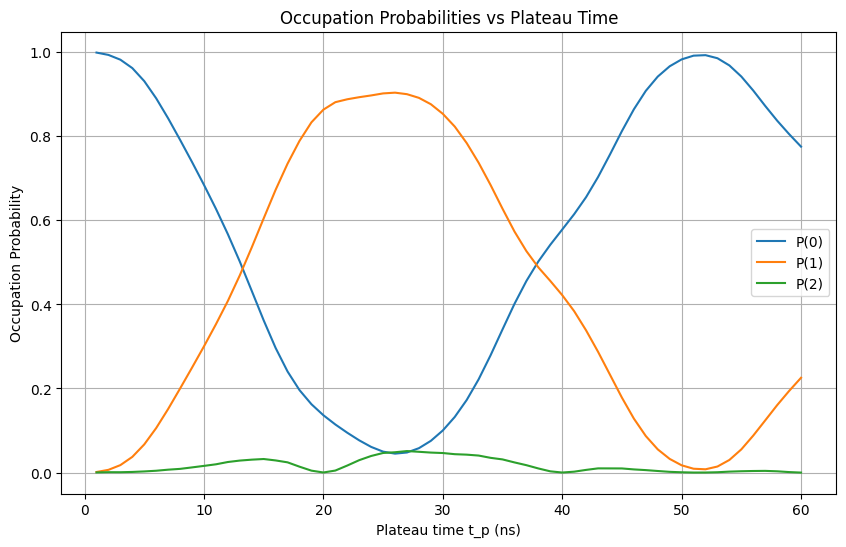

In [ ]:
# time grid
dt_sim = 0.0001
dt_t_p = 1
t_r = 0 # no ramp case
t_p_array = np.arange(dt_t_p, 60.0 + 0.5*dt_t_p, dt_t_p)

# state for simulation, displaced initial state
q0_init = displacement(steady_state_displacement(0)) * evecs[0]

expectation_results = {"p0": [], "p1": [], "p2": []}
for t_p in t_p_array:
    # additional states for probability calculations, displaced final states important that these are displaced by steady state at t_p
    q0_final = displacement(steady_state_displacement(t_p)) * evecs[0]  
    q1_final = displacement(steady_state_displacement(t_p)) * evecs[1]
    q2_final = displacement(steady_state_displacement(t_p)) * evecs[2]
    e_ops = [q0_final*q0_final.dag(), q1_final*q1_final.dag(), q2_final*q2_final.dag()]

    times = make_time_array(t_r, t_p, dt_sim)
    print(times)
    states, expect = run(q0_init, times, e_ops, t_r, t_p)
    expectation_results["p0"].append(expect[0][-1]) # append final probabilities
    expectation_results["p1"].append(expect[1][-1])
    expectation_results["p2"].append(expect[2][-1])

# Plot results
plt.figure(figsize=(10,6))
plt.plot(t_p_array, expectation_results["p0"], label="P(0)")
plt.plot(t_p_array, expectation_results["p1"], label="P(1)")
plt.plot(t_p_array, expectation_results["p2"], label="P(2)")
plt.xlabel("Plateau time t_p (ns)")
plt.ylabel("Occupation Probability")
plt.title("Occupation Probabilities vs Plateau Time")
plt.legend()
plt.grid()
plt.show()

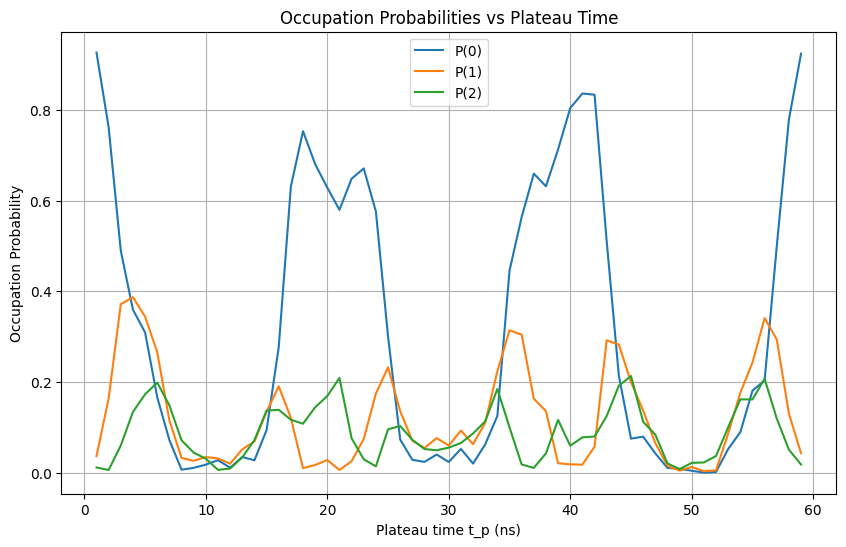

In [8]:
# time grid
dt_sim = 0.001
dt_t_p = 1
t_r = 0 # no ramp case
t_p_array = np.arange(dt_t_p, 60.0, dt_t_p)

# state for simulation, bare initial state
q0_init = evecs[0]

expectation_results = {"p0": [], "p1": [], "p2": []}
for t_p in t_p_array:
    # additional states for probability calculations, bare final states, result is totally not correct so we really do need the displacement as theoretically expected
    q0_final = evecs[0]  
    q1_final = evecs[1]
    q2_final = evecs[2]
    e_ops = [q0_final*q0_final.dag(), q1_final*q1_final.dag(), q2_final*q2_final.dag()]

    times = make_time_array(t_r, t_p, dt_sim)
    states, expect = run(q0_init, times, e_ops, t_r, t_p)
    expectation_results["p0"].append(expect[0][-1]) # append final probabilities
    expectation_results["p1"].append(expect[1][-1])
    expectation_results["p2"].append(expect[2][-1])

# Plot results
plt.figure(figsize=(10,6))
plt.plot(t_p_array, expectation_results["p0"], label="P(0)")
plt.plot(t_p_array, expectation_results["p1"], label="P(1)")
plt.plot(t_p_array, expectation_results["p2"], label="P(2)")
plt.xlabel("Plateau time t_p (ns)")
plt.ylabel("Occupation Probability")
plt.title("Occupation Probabilities vs Plateau Time")
plt.legend()
plt.grid()
plt.show()

In [9]:
kappa = 0.0 # no decay
A = beta*(a + a.dag())
A2 = A*A

# Key simplification for simulating H_disp efficiently:
# The drive-induced shift enters as a real scalar s(t) multiplying the identity,
# so it COMMUTES with the operator A = β(a + a†). Therefore we can use:
#
#   cos(A + sI) = cos(s) * cos(A) - sin(s) * sin(A),     s ∈ ℝ
#
# with:
#   A = β(a + a†)
#   s(t) = β(ξ(t) + ξ*(t)) = 2β * Re[ξ(t)]    (a real number)
#
# For the "nonlinear cosine" used in the paper/code:
#   cos_nl(A + sI) = cos(A + sI) - I + 1/2 (A + sI)^2
#
# and:
#   (A + sI)^2 = A^2 + 2sA + s^2 I
#
# Dropping pure-identity terms (they only add a global phase), the Hamiltonian
# can be built from time-INDEPENDENT operators n, A^2, A, cos(A), sin(A, and
# only scalar time-dependent coefficients cos(s(t)), sin(s(t)), and s(t).
# This avoids recomputing matrix cos/sin at every timestep.

# precompute once
cosA = A.cosm()
sinA = A.sinm()

def xi(t, w, w_d, kappa, g0):
    # Eq (C23)-style (with kappa)
    return -(g0/2) * (
        np.exp(1j*w_d*t) / (w + w_d - 1j*kappa/2)
        - np.exp(-1j*w_d*t) / (w - w_d - 1j*kappa/2)
    )

def cos_nl_op(X):
    I = qt.qeye(X.dims[0][0])
    return X.cosm() - I + 0.5*(X*X)

def s_of_t(t, args):
    x = xi(t, args["w"], args["w_d"], args["kappa"], args["g0"])
    return args["beta"] * (x + np.conj(x)) 

# time-dependent scalar coefficients
# coefficent for cosA
def c_cosA(t, args):
    return -args["Ej"] * np.cos(s_of_t(t, args))

# coefficent for sinA
def c_sinA(t, args):
    return +args["Ej"] * np.sin(s_of_t(t, args))

def c_A(t, args):
    return -args["Ej"] * s_of_t(t, args)

# static part (dropping identity-only terms)
H0 = w*n - (Ej/2)*A2

# full time-dependent Hamiltonian (list form)
H = [
    H0,
    [cosA, c_cosA],
    [sinA, c_sinA],
    [A,    c_A],
]

args = dict(w=w, Ej=Ej, beta=beta, w_d=w_d, g0=g_0, kappa=kappa)

def run_displaced_frame(psi_0, times, e_ops):
    res = qt.sesolve(H, psi_0, times, args=args, e_ops=e_ops, options={"store_states": True})

    return res.states, res.expect

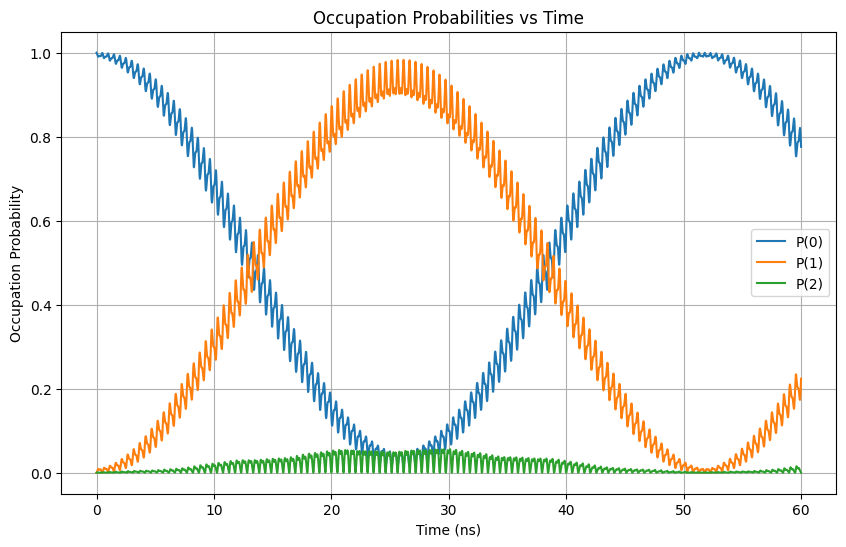

In [10]:
# time grid
dt_sim = 0.001
times = np.arange(0, 60.0, dt_sim)

# state for simulation
q0 = evecs[0] 

# additional states for probability calculations
q1 = evecs[1]
q2 = evecs[2]

e_ops = [q0*q0.dag(), q1*q1.dag(), q2*q2.dag()]

states, expect = run_displaced_frame(q0, times, e_ops)

p0 = expect[0]
p1 = expect[1]
p2 = expect[2]

plt.figure(figsize=(10,6))
plt.plot(times, p0, label="P(0)")
plt.plot(times, p1, label="P(1)")
plt.plot(times, p2, label="P(2)")
plt.xlabel("Time (ns)")
plt.ylabel("Occupation Probability")
plt.title("Occupation Probabilities vs Time")
plt.legend()
plt.grid()
plt.show()


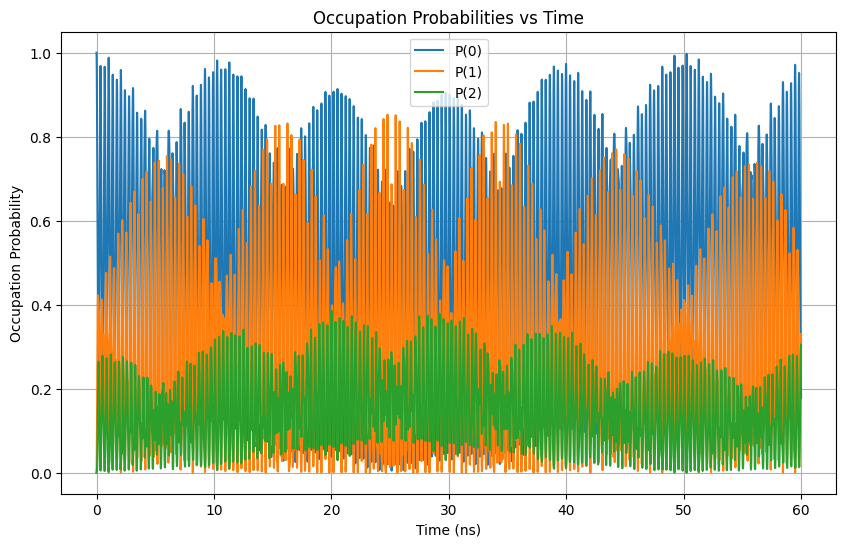

In [11]:
# time grid
dt_sim = 0.001
times = np.arange(0, 60.0, dt_sim)

# state for simulation. using displaced states which seems wrong
q0 = displacement(steady_state_displacement(0)) * evecs[0] 

# additional states for probability calculations
q1 = displacement(steady_state_displacement(0)) * evecs[1]
q2 = displacement(steady_state_displacement(0)) * evecs[2]
e_ops = [q0*q0.dag(), q1*q1.dag(), q2*q2.dag()]

states, expect = run_displaced_frame(q0, times, e_ops)

p0 = expect[0]
p1 = expect[1]
p2 = expect[2]

plt.figure(figsize=(10,6))
plt.plot(times, p0, label="P(0)")
plt.plot(times, p1, label="P(1)")
plt.plot(times, p2, label="P(2)")
plt.xlabel("Time (ns)")
plt.ylabel("Occupation Probability")
plt.title("Occupation Probabilities vs Time")
plt.legend()
plt.grid()
plt.show()